# Learned Parameter Heatmaps from CSV

`v_matrix.csv` と `w_matrix.csv` を読み込み、CairoMakie で横並びの heatmap を描画するノートブックです。

既定では `results/latest_learned_parameter_heatmap/M{M}_N{N}` を見にいきます。必要なら `results_root` を調整してください。


In [14]:
using CairoMakie
using DelimitedFiles

function detect_results_root()
    candidates = [
        joinpath(pwd(), "results", "latest_learned_parameter_heatmap"),
        joinpath(pwd(), "learned_parameter_heatmap", "results", "latest_learned_parameter_heatmap"),
    ]

    for dir in candidates
        if isdir(dir)
            return dir
        end
    end

    error("results directory not found. Please set results_root manually.")
end

function load_parameter_matrices(results_root::AbstractString, M::Integer, N::Integer)
    data_dir = joinpath(results_root, "M$(M)_N$(N)")
    v_path = joinpath(data_dir, "v_matrix.csv")
    w_path = joinpath(data_dir, "w_matrix.csv")

    if !isfile(v_path) || !isfile(w_path)
        error("CSV files not found in $(data_dir)")
    end

    v_matrix = Matrix{Float64}(readdlm(v_path, ',', Float64))
    w_matrix = Matrix{Float64}(readdlm(w_path, ',', Float64))
    return v_matrix, w_matrix, data_dir
end

function plot_parameter_heatmaps(v_matrix, w_matrix; M::Integer, N::Integer)
    color_limit = maximum(abs, vcat(vec(v_matrix), vec(w_matrix)))
    color_limit = color_limit == 0 ? 1.0 : color_limit

    fig = Figure(size = (1200, 520))

    ax_w = Axis(fig[1, 1], title = "Learned W", xlabel = "column", ylabel = "row", yreversed = true)
    hm_w = heatmap!(ax_w, w_matrix'; colormap =:RdBu, colorrange = (-color_limit, color_limit))
    Colorbar(fig[1, 2], hm_w)

    ax_v = Axis(fig[1, 3], title = "Learned V", xlabel = "column", ylabel = "row", yreversed = true)
    hm_v = heatmap!(ax_v, v_matrix'; colormap = :RdBu, colorrange = (-color_limit, color_limit))
    Colorbar(fig[1, 4], hm_v)

    Label(fig[0, 1:4], "Learned parameter heatmaps (M=$(M), N=$(N))", fontsize = 22)
    return fig
end


plot_parameter_heatmaps (generic function with 1 method)

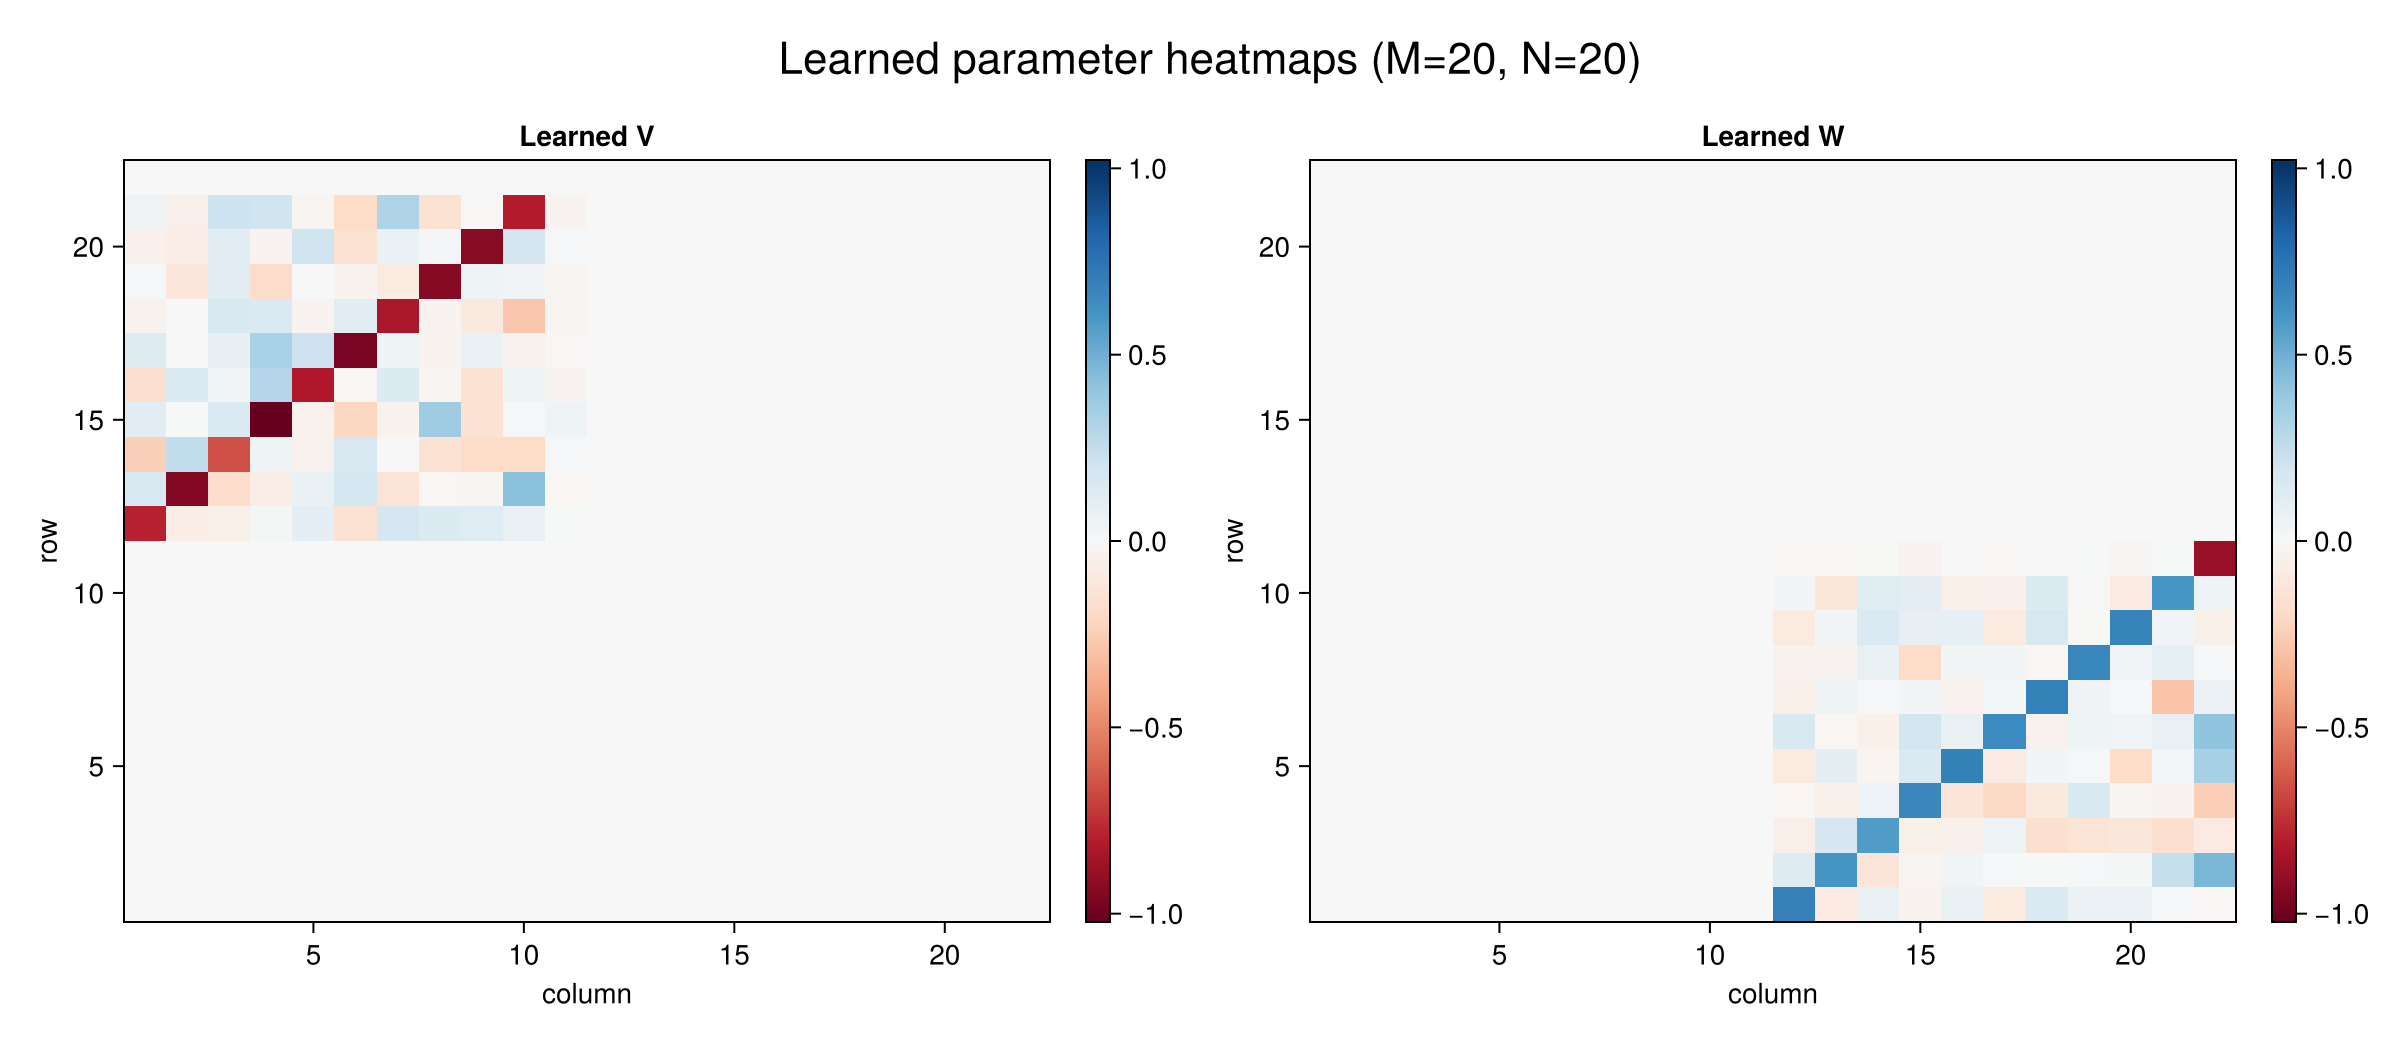

CairoMakie.Screen{PDF}


In [15]:
M = 20
N = 20

results_root = detect_results_root()
v_matrix, w_matrix, data_dir = load_parameter_matrices(results_root, M, N)

fig = plot_parameter_heatmaps(v_matrix, w_matrix; M = M, N = N)
display(fig)

save(joinpath(data_dir, "learned_parameter_heatmaps_makie.pdf"), fig)
